### Model inspired by:

- [1] Offshore Pipelaying Dynamics. Gullik Anthon Jensen
- [2] A nonlinear PDE formulation for offshore vessel pipeline installation. Gullik A. Jensen et al
- [3] Modeling and Control of Offshore Pipelay Operations Based on a Finite Strain Pipe Model. Gullik A. Jensen

### Implementation aspects:

- The model can be applied to normal dynamic pipelay condition as a rough estimate

In [1]:
import numpy as np
import inspect
import matplotlib.pyplot as plt
import scipy
from datetime import datetime
from scipy.optimize import root
from scipy.integrate import solve_ivp
from scipy import interpolate
import plotly.graph_objects as go
from scipy.interpolate import interp1d

In [2]:
import sys

In [3]:
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src/python_vehicle_simulator")
sys.path.insert(0, "../../../../miscellaneous/Ocean_Intella_1/PythonVehicleSimulator-master/src")

In [4]:
from python_vehicle_simulator.vehicles import *
from python_vehicle_simulator.lib import *
from python_vehicle_simulator.lib.gnc import ssa

### Modelling data:

In [5]:
mp = 41.9       #  (submerged pipe weight) [kg/m]
N = 50       # number of modelling nodes

In [6]:
mi = [mp for i in range(N)]

In [7]:
# Vessel:

# L - the hull length
# Xg - x-center of gravity

L = 168 # [m]
B = 46
H = 13.5
Xg = L/2 # [m]
mn = 39_989_000  # mass of the vessel, [kg]

In [8]:
Fx_0 = 449*1000
Fy_0 = 0.7*Fx_0
LTD = 387

In [9]:
lx, ly, lz = L/2, B/2, H/2

In [10]:
vessel_mass = mn/L # mass over length of the vessel

In [11]:
diag_Jrho0 = 1e2*np.array([1, 1, 2]) # [m^4] 
Jrho0 = np.diag(diag_Jrho0)

In [12]:
qw = 1025 # Water density [kg/m3]
d0 = 0.2731 # Outer diameter of pipe, [m]
dI= (273.1-15.9*2)/1000 # Inner diameter of pipe, [m]

In [13]:
rho_steel=7850 #kg/m^3

In [14]:
Ar=np.pi*(d0/2)**2

Iy_ = 1/4*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
Iz_ = 1/2*np.pi*rho_steel*((d0/2)**4-(dI/2)**4)
J_ = 1/32*np.pi*(d0**4-dI**4)

In [15]:
E = 207e9
G = 79.3e9

In [16]:
h = 90 # water depth

In [17]:
# Fossen book p.181
def vessel_inertia_moment(mn, Xg, L):
    r = 0.25*L
    Ir = mn*r**2
    Iz=mn*Xg**2 + Ir
    return Iz

In [18]:
vessel_inertia = vessel_inertia_moment(mn, Xg, L)

In [19]:
# Underwater current: 
dv1_curr = np.zeros(N)
dv2_curr = np.zeros(N)
dv3_curr = np.zeros(N)

In [20]:
# Constants: 

In [21]:
diag_DT = 1.5*np.array([1, 1, 1])
DT=np.diag(diag_DT)

In [22]:
diag_CT = 1e9*np.array([1, 1, 1 ])  
CT=np.diag(diag_CT)

In [23]:
# diag_CR = 1e11*np.array([1, 1, 1]) 
diag_CR = 1e9*np.array([1, 1, 1])        ### !!! ### !!! ### !!! ### affects bending strain                
CR=np.diag(diag_CR)

In [24]:
diag_DR = 1.5*np.array([1, 1, 1])
DR=np.diag(diag_DR)

In [25]:
# for testing:

In [26]:
φ = np.random.rand(N)
θ = np.random.rand(N)
ψ = np.random.rand(N)

In [27]:
φ

array([0.63598022, 0.30853977, 0.50569241, 0.76659102, 0.54090478,
       0.85224313, 0.06790992, 0.184886  , 0.04683605, 0.25168223,
       0.91250891, 0.36777253, 0.81643133, 0.95976911, 0.74392412,
       0.178863  , 0.77236892, 0.03150088, 0.40394973, 0.01652203,
       0.28277435, 0.9249546 , 0.52346985, 0.79914632, 0.22559159,
       0.11555753, 0.65036799, 0.34456561, 0.54008987, 0.66756683,
       0.19887191, 0.97184678, 0.99045184, 0.97389397, 0.61492054,
       0.82732154, 0.01545133, 0.2809556 , 0.86797765, 0.89559014,
       0.36990877, 0.57794576, 0.0114018 , 0.96581443, 0.33971106,
       0.68098385, 0.32551595, 0.5551315 , 0.88311837, 0.90748705])

In [28]:
dφ = np.random.rand(N)
dθ = np.random.rand(N)
dψ = np.random.rand(N)

In [29]:
ddφ = np.random.rand(N)
ddθ = np.random.rand(N)
ddψ = np.random.rand(N)

In [30]:
x = np.random.rand(N)
y = np.random.rand(N)
z = np.random.rand(N)

In [31]:
dx = np.random.rand(N)
dy = np.random.rand(N)
dz = np.random.rand(N)

In [32]:
# integration parameters
tspan = (0., 10)

### Main functions:

In [33]:
def Π0(φθψ):
    φ0,θ0,ψ0=φθψ
    return np.array([[np.cos(θ0),0,np.cos(φ0)*np.sin(θ0)],
                  [0,1,-np.sin(φ0)],
                  [-np.sin(θ0),0,np.cos(φ0)*np.cos(θ0)]])

In [34]:
def Π(φ,θ,ψ):
    φθψ=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Π0, 1, φθψ)

In [35]:
Π(φ,θ,ψ)

array([[[ 0.9548915 ,  0.        ,  0.23889723],
        [ 0.        ,  1.        , -0.59396637],
        [-0.29695492,  0.        ,  0.76820053]],

       [[ 0.82477388,  0.        ,  0.53876041],
        [ 0.        ,  1.        , -0.30366768],
        [-0.56546268,  0.        ,  0.78582642]],

       [[ 0.99682726,  0.        ,  0.06963311],
        [ 0.        ,  1.        , -0.4844133 ],
        [-0.07959531,  0.        ,  0.87206364]],

       [[ 0.95598503,  0.        ,  0.21134115],
        [ 0.        ,  1.        , -0.69368386],
        [-0.29341543,  0.        ,  0.68857652]],

       [[ 0.76416532,  0.        ,  0.55293935],
        [ 0.        ,  1.        , -0.51491182],
        [-0.64502044,  0.        ,  0.65507548]],

       [[ 0.99971829,  0.        ,  0.01562461],
        [ 0.        ,  1.        , -0.75275894],
        [-0.02373492,  0.        ,  0.65811082]],

       [[ 0.84457746,  0.        ,  0.53419922],
        [ 0.        ,  1.        , -0.06785774],
        

In [36]:
def dΠ0(φ0, θ0, ψ0, dφ0, dθ0, dψ0):
    """Time derivative of Π0 via chain rule: dΠ/dt = ∂Π/∂φ·dφ + ∂Π/∂θ·dθ + ∂Π/∂ψ·dψ"""
    
    # ∂Π/∂φ
    dPi_dphi = np.array([
        [0,              0,  -np.sin(φ0)*np.sin(θ0)],
        [0,              0,  -np.cos(φ0)            ],
        [0,              0,  -np.sin(φ0)*np.cos(θ0)]
    ])
    
    # ∂Π/∂θ
    dPi_dtheta = np.array([
        [-np.sin(θ0),   0,   np.cos(φ0)*np.cos(θ0)],
        [0,              0,   0                     ],
        [-np.cos(θ0),   0,  -np.cos(φ0)*np.sin(θ0)]
    ])
    
    # ∂Π/∂ψ — Π0 as defined doesn't depend on ψ, so this is zero
    dPi_dpsi = np.zeros((3, 3))
    
    return dPi_dphi * dφ0 + dPi_dtheta * dθ0 + dPi_dpsi * dψ0


def dΠ(φ, θ, ψ, dφ, dθ, dψ):
    return np.array([dΠ0(φ[i], θ[i], ψ[i], dφ[i], dθ[i], dψ[i]) for i in range(len(φ))])

In [37]:
dΠ(φ, θ, ψ, dφ, dθ, dψ)

array([[[-0.04921989,  0.        ,  0.05809925],
        [ 0.        ,  0.        , -0.31575928],
        [-0.15827202,  0.        , -0.26221037]],

       [[-0.14315382,  0.        ,  0.09012403],
        [ 0.        ,  0.        , -0.60379325],
        [-0.20880163,  0.        , -0.29511321]],

       [[-0.07109855,  0.        ,  0.74365147],
        [ 0.        ,  0.        , -0.80138645],
        [-0.89041635,  0.        , -0.50453315]],

       [[-0.28307734,  0.        ,  0.48218087],
        [ 0.        ,  0.        , -0.64453877],
        [-0.92230223,  0.        , -0.7973127 ]],

       [[-0.24823565,  0.        ,  0.11673594],
        [ 0.        ,  0.        , -0.3493962 ],
        [-0.29408848,  0.        , -0.37317245]],

       [[-0.02081573,  0.        ,  0.56692808],
        [ 0.        ,  0.        , -0.37732298],
        [-0.87676165,  0.        , -0.44504856]],

       [[-0.34474838,  0.        ,  0.53347734],
        [ 0.        ,  0.        , -0.24893516],
        

In [38]:
def w_e(φ,θ,ψ,dφ,dθ,dψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), np.stack((dφ,dθ,dψ), axis=1))

In [39]:
w_e(φ,θ,ψ,dφ,dθ,dψ)

array([[ 0.39184635,  0.12334515, -0.0617115 ],
       [ 0.96721676,  0.00259992,  0.290057  ],
       [ 0.93371475,  0.75006437,  0.18485787],
       [ 1.06114996,  0.28962698,  0.4076072 ],
       [ 0.41456264,  0.28883683, -0.14075029],
       [ 0.58302246,  0.39509415,  0.40771664],
       [ 0.72450099,  0.5786052 ,  0.67681047],
       [ 0.93236191,  0.35216125, -0.04489838],
       [ 0.59937392,  0.74281995, -0.03071568],
       [ 0.41878432,  0.27928637,  0.58059306],
       [ 0.67276486, -0.23151435, -0.27770987],
       [ 0.96007111, -0.18346452, -0.28061678],
       [ 0.3866048 , -0.05088028,  0.20956101],
       [ 0.49537981,  0.29113289, -0.14406439],
       [ 0.81881991,  0.87591507, -0.05633188],
       [ 1.03447596,  0.22320313,  0.0619611 ],
       [ 0.1527752 ,  0.1158448 , -0.00478625],
       [ 0.23923979,  0.88155945,  0.19389491],
       [ 0.81591034, -0.00332173,  0.36178217],
       [ 0.43814342,  0.59861785,  0.38448374],
       [ 0.25608385,  0.7196188 , -0.100

In [40]:
def dw_e(φ, θ, ψ, dφ, dθ, dψ, ddφ, ddθ, ddψ):
    """ẇ = Π·[ddφ,ddθ,ddψ] + dΠ·[dφ,dθ,dψ]"""
    return (
        np.einsum('ijk,ik->ij', Π(φ, θ, ψ),   np.stack((ddφ, ddθ, ddψ), axis=1)) +
        np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ, dθ, dψ), axis=1))
    )

In [41]:
dw_e(φ,θ,ψ,dφ,dθ,dψ,ddφ,ddθ,ddψ)

array([[ 6.02200618e-01,  7.09720672e-01, -2.11890397e-01],
       [ 1.06797043e+00,  2.68151008e-01, -3.56115720e-01],
       [ 8.23925187e-01, -4.48406482e-01, -4.86750152e-01],
       [ 5.43308660e-01, -7.05601497e-01, -1.33072831e+00],
       [ 9.41440763e-01, -4.87976442e-01, -3.07834843e-04],
       [ 1.23145139e+00,  3.85025937e-01, -6.10914463e-01],
       [ 9.71866789e-01,  1.18437070e-01,  2.81074349e-01],
       [ 8.67946521e-01,  5.19472558e-01,  2.49532804e-01],
       [ 8.14943325e-01,  6.32834807e-01, -8.02709294e-01],
       [ 8.54061456e-01,  1.09735300e-01, -8.73488213e-02],
       [ 8.73451481e-01, -3.02735318e-02, -4.86168833e-01],
       [ 7.09178195e-01, -6.27061872e-01,  1.19015121e-01],
       [ 8.19091864e-01,  9.25718171e-02, -2.86816367e-01],
       [ 6.16927619e-01, -1.50929318e-01, -6.56777504e-01],
       [ 1.14114258e-01, -4.21319369e-01, -1.11906312e-01],
       [ 4.81149342e-01, -2.01633405e-01, -3.90663138e-01],
       [ 3.64983685e-01, -5.83727765e-02

In [42]:
def phi(x,y,z): return np.stack((x,y,z), axis=1) 
def theta(φ,θ,ψ): return np.stack((φ,θ,ψ), axis=1) 

In [43]:
phi(x,y,z)

array([[4.21536664e-01, 6.64471259e-01, 6.52105958e-01],
       [2.65642746e-01, 1.41185017e-01, 7.27586537e-01],
       [3.26917656e-01, 6.80554926e-01, 1.72927581e-01],
       [3.18286548e-01, 4.85688303e-01, 3.45828361e-01],
       [2.06272614e-01, 1.91957921e-01, 8.89354807e-01],
       [5.64180591e-01, 2.01194619e-01, 9.36383397e-01],
       [5.19723759e-01, 6.12138133e-01, 6.04085569e-01],
       [6.50734689e-01, 2.43816970e-01, 3.55531562e-01],
       [8.68540540e-01, 6.85471030e-01, 8.11927238e-02],
       [6.89594424e-02, 8.96730570e-01, 1.47615336e-01],
       [3.03037541e-01, 6.54913862e-01, 4.85722728e-01],
       [8.04503788e-01, 1.54926946e-01, 1.67255989e-01],
       [8.42516367e-01, 8.12339094e-01, 5.97546080e-01],
       [7.56183574e-01, 3.57874929e-01, 5.72568657e-01],
       [7.77440029e-01, 1.75706296e-01, 7.45962611e-01],
       [7.72957267e-01, 6.99673579e-01, 3.14792442e-01],
       [8.92037998e-02, 5.51178563e-01, 6.72455663e-01],
       [1.43936061e-01, 5.25982

In [44]:
theta(φ,θ,ψ)

array([[6.35980216e-01, 3.01502142e-01, 2.09904149e-01],
       [3.08539768e-01, 6.00994124e-01, 3.70891627e-02],
       [5.05692406e-01, 7.96795981e-02, 5.12984648e-01],
       [7.66591024e-01, 2.97797571e-01, 3.16559928e-01],
       [5.40904781e-01, 7.01050030e-01, 5.56052325e-01],
       [8.52243128e-01, 2.37371449e-02, 6.94411146e-01],
       [6.79099245e-02, 5.65020813e-01, 9.81586423e-01],
       [1.84885999e-01, 2.87026645e-01, 2.50388927e-01],
       [4.68360486e-02, 9.11178897e-01, 7.28586523e-01],
       [2.51682228e-01, 1.84881839e-01, 7.58445354e-01],
       [9.12508909e-01, 7.70880372e-01, 8.21962612e-01],
       [3.67772534e-01, 9.85354598e-01, 6.67244521e-01],
       [8.16431329e-01, 1.47411981e-01, 9.50103291e-01],
       [9.59769114e-01, 6.18847354e-01, 8.21160873e-04],
       [7.43924122e-01, 1.41869192e-01, 7.61672966e-01],
       [1.78862995e-01, 5.82111009e-01, 7.88006466e-01],
       [7.72368923e-01, 6.36497536e-01, 7.87565542e-01],
       [3.15008814e-02, 5.99729

In [45]:
def ω(φ,θ,ψ): 
    return np.einsum('ijk,ik->ij', Π(φ,θ,ψ), theta(φ,θ,ψ))

In [46]:
ω(x,y,z)

array([[ 0.69876755,  0.39765357,  0.2084888 ],
       [ 0.36179177, -0.04982793,  0.65769979],
       [ 0.35713544,  0.62502348, -0.07841962],
       [ 0.43480798,  0.3774649 ,  0.14189186],
       [ 0.36855925,  0.00980653,  0.81515968],
       [ 0.7109275 , -0.29951166,  0.66256239],
       [ 0.72663701,  0.31212484,  0.13047162],
       [ 0.69977666,  0.02844622,  0.11741549],
       [ 0.70555556,  0.62348956, -0.50921957],
       [ 0.15809859,  0.88655916,  0.03804038],
       [ 0.52270796,  0.50996414,  0.18309639],
       [ 0.81276577,  0.03442124, -0.00954369],
       [ 0.86818807,  0.3663783 , -0.33802897],
       [ 0.8541751 , -0.03499314,  0.12525193],
       [ 0.85840545, -0.34755455,  0.38757113],
       [ 0.73646704,  0.47986811, -0.32535991],
       [ 0.42675262,  0.49127248,  0.52387727],
       [ 0.29652867,  0.47631428,  0.22409792],
       [ 0.59862336,  0.54642179,  0.59106933],
       [ 0.56257675,  0.59644475, -0.17820158],
       [ 0.48382298, -0.09191637,  0.409

In [47]:
def Ret(φ,θ,ψ):
    
    def Ret0(arr):
        φ,θ,ψ=arr
        Cφ=np.matrix([[1,0,0],
                      [0,np.cos(φ),-np.sin(φ)],
                      [0,np.sin(φ),np.cos(φ)]])

        Cθ=np.matrix([[np.cos(θ),0,np.sin(θ)],
                      [0,1,0],
                      [-np.sin(θ),0,np.cos(θ)]])

        Cψ=np.matrix([[np.cos(ψ),-np.sin(ψ),0],
                      [np.sin(ψ),np.cos(ψ),0],
                      [0,0,1]])

        return np.array(Cθ @ Cφ @ Cψ)
    
    arr=np.stack((φ,θ,ψ), axis=1)
    return np.apply_along_axis(Ret0, 1, arr)

In [48]:
Ret(φ,θ,ψ)

array([[[ 9.70684361e-01, -2.64572402e-02,  2.38897227e-01],
        [ 1.67628459e-01,  7.86832032e-01, -5.93966374e-01],
        [-1.72257280e-01,  6.16599844e-01,  7.68200535e-01]],

       [[ 8.30573888e-01,  1.41011491e-01,  5.38760407e-01],
        [ 3.53296374e-02,  9.52122762e-01, -3.03667683e-01],
        [-5.55786680e-01,  2.71252658e-01,  7.85826419e-01]],

       [[ 8.87442243e-01, -4.55628681e-01,  6.96331055e-02],
        [ 4.29353535e-01,  7.62233098e-01, -4.84413301e-01],
        [ 1.67635936e-01,  4.59786046e-01,  8.72063636e-01]],

       [[ 9.71845073e-01, -1.04173280e-01,  2.11341150e-01],
        [ 2.24222512e-01,  6.84490300e-01, -6.93683858e-01],
        [-7.23976442e-02,  7.21540683e-01,  6.88576520e-01]],

       [[ 8.24350254e-01, -1.21263061e-01,  5.52939353e-01],
        [ 4.52484978e-01,  7.28095572e-01, -5.14911820e-01],
        [-3.40152911e-01,  6.74664441e-01,  6.55075484e-01]],

       [[ 7.79647658e-01, -6.26023482e-01,  1.56246065e-02],
        [ 4.21

In [49]:
def d_s(func, a, b, c, φ, θ, ψ): 
    
    sig = inspect.signature(func)
    num_args = len(sig.parameters)
    
    if num_args==3:
        fu = func(a, b, c)
    else:
        fu = func(a, b, c, φ, θ, ψ)

    def S(arr):
        a1, a2, a3 = arr[0],arr[1],arr[2]
        return np.array([[0, -a3, a2 ],
                         [a3, 0, -a1],
                        [-a2, a1, 0]])
    
    S0 = np.apply_along_axis(S, 1, ω(φ,θ,ψ))

    
    return np.einsum('ijk,ik->ij',S0, fu).T

In [50]:
d_s(phi,x,y,z,φ, θ, ψ).T

array([[ 1.33654749e-01, -4.40357186e-01,  3.62309704e-01],
       [ 4.49597887e-01, -2.38295495e-01, -1.17908536e-01],
       [-3.06250095e-01,  3.97418419e-02,  4.22558717e-01],
       [ 3.04229566e-02, -2.78790148e-01,  3.63538420e-01],
       [ 3.65895219e-01, -6.37881723e-01,  5.28161377e-02],
       [-5.55119282e-01, -5.61543127e-01,  4.55120180e-01],
       [-1.82966602e-01,  5.95660590e-02,  9.70548495e-02],
       [ 4.08899676e-02,  3.17310334e-02, -9.66020699e-02],
       [-2.09137757e-01,  3.06196710e-01, -3.47868044e-01],
       [-6.06569402e-01, -9.85150223e-03,  3.43208451e-01],
       [ 2.38791247e-01, -5.71476600e-01,  6.21558798e-01],
       [ 1.18869504e-01, -9.06032000e-02, -4.87839566e-01],
       [-7.51031237e-01, -9.84591884e-02,  1.19277555e+00],
       [ 5.53060207e-01, -8.68499593e-01, -1.87577180e-01],
       [-3.57934729e-01, -2.58913472e-01,  4.34023782e-01],
       [-2.45279812e-01,  2.43417254e-01,  6.12409621e-02],
       [ 6.14410585e-02, -6.43633836e-01

In [51]:
d_s(theta, φ, θ, ψ, φ, θ, ψ).T

array([[ 4.54407053e-02, -1.55557647e-01,  8.57609266e-02],
       [ 1.09210358e-01, -5.50170476e-02, -1.70080981e-02],
       [-1.19038447e-01, -7.10439106e-02,  1.28381209e-01],
       [ 2.68274432e-02, -2.58500135e-01,  1.78212813e-01],
       [ 2.19843503e-01, -3.92495511e-01,  2.80989002e-01],
       [-3.56869882e-01, -2.26939132e-01,  4.45739953e-01],
       [ 4.24427634e-02, -5.17306371e-01,  2.94835559e-01],
       [ 7.61285715e-03, -2.78803766e-02,  2.63386258e-02],
       [ 2.66358401e-01, -4.20779010e-01,  5.09108758e-01],
       [-1.27967864e-01, -1.19970896e-01,  7.17094208e-02],
       [ 3.11270920e-01, -1.07704157e+00,  6.64546916e-01],
       [ 4.60433771e-01, -4.68058645e-01,  4.37424114e-01],
       [-5.94941149e-01, -4.30529449e-01,  5.78035880e-01],
       [ 3.44818892e-01, -5.34633845e-01, -1.09334890e-01],
       [-3.48594814e-01, -2.86798248e-01,  3.93890738e-01],
       [ 2.84284626e-02, -3.55414131e-01,  2.56096475e-01],
       [ 7.19092929e-02, -7.57444807e-01

In [52]:
def ne(x, y, z, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp',RET, CT), np.transpose(RET,(0,2,1))) 
    B = d_s(phi, x, y, z, φ, θ, ψ).T
    t1=np.einsum('ijk,kp->ijp',RET, np.array([0,0,1]).reshape(3,1)).squeeze()
    return np.einsum('ijk,ik->ij', A, B 
#                      - t1
                    )

In [53]:
ne(x, y, z, φ, θ, ψ)

array([[ 1.33654749e+08, -4.40357186e+08,  3.62309704e+08],
       [ 4.49597887e+08, -2.38295495e+08, -1.17908536e+08],
       [-3.06250095e+08,  3.97418419e+07,  4.22558717e+08],
       [ 3.04229566e+07, -2.78790148e+08,  3.63538420e+08],
       [ 3.65895219e+08, -6.37881723e+08,  5.28161377e+07],
       [-5.55119282e+08, -5.61543127e+08,  4.55120180e+08],
       [-1.82966602e+08,  5.95660590e+07,  9.70548495e+07],
       [ 4.08899676e+07,  3.17310334e+07, -9.66020699e+07],
       [-2.09137757e+08,  3.06196710e+08, -3.47868044e+08],
       [-6.06569402e+08, -9.85150223e+06,  3.43208451e+08],
       [ 2.38791247e+08, -5.71476600e+08,  6.21558798e+08],
       [ 1.18869504e+08, -9.06032000e+07, -4.87839566e+08],
       [-7.51031237e+08, -9.84591884e+07,  1.19277555e+09],
       [ 5.53060207e+08, -8.68499593e+08, -1.87577180e+08],
       [-3.57934729e+08, -2.58913472e+08,  4.34023782e+08],
       [-2.45279812e+08,  2.43417254e+08,  6.12409621e+07],
       [ 6.14410585e+07, -6.43633836e+08

In [54]:
d_s(ne, x, y, z, φ, θ, ψ).T

array([[ 5.19080134e+07, -2.41886100e+08, -3.13141033e+08],
       [-1.04163956e+08, -3.29755927e+07, -3.30544003e+08],
       [-8.75141734e+07, -3.52776663e+08, -3.02472271e+07],
       [ 2.64918643e+07, -2.90952023e+08, -2.25342120e+08],
       [ 3.17034362e+07, -3.24493392e+07, -6.11536124e+08],
       [ 1.81669948e+07, -6.35162105e+08, -7.61526474e+08],
       [ 1.27128066e+06, -2.01140047e+08,  1.25843498e+08],
       [-2.91101091e+07,  3.13726315e+07, -2.01678289e+06],
       [-4.30334366e+08,  1.24514556e+08,  3.68315267e+08],
       [ 5.28567387e+06, -5.41150339e+08, -6.19161830e+06],
       [-8.22160649e+07, -6.90304073e+08, -6.03096842e+08],
       [-3.60263320e+08,  3.56756937e+08, -1.54041712e+08],
       [-5.98423217e+08, -1.47055017e+09, -4.98185684e+08],
       [-5.99167046e+08, -1.61014025e+08, -1.02109881e+09],
       [-4.58740219e+07, -5.14970846e+08, -3.45033617e+08],
       [-1.06666941e+08, -1.70011850e+08,  2.48535782e+08],
       [ 4.16374305e+07, -4.97101790e+08

In [55]:
def me(a, b, c, φ, θ, ψ):
    RET = Ret(φ,θ,ψ)
    A = np.einsum('ijk,ikp->ijp',np.einsum('ijk,kp->ijp', RET, CR), np.transpose(RET,(0,2,1))) 
    return np.einsum('ijk,ik->ij', A, ω(φ,θ,ψ))

In [56]:
me(φ, θ, ψ, φ, θ, ψ)

array([[ 6.57437621e+08,  1.76826136e+08, -2.76089772e+07],
       [ 2.74457715e+08,  5.89731344e+08, -1.45322080e+08],
       [ 5.39808690e+08, -1.68816989e+08,  4.07104512e+08],
       [ 7.99751685e+08,  7.82050593e+07, -6.95390244e+06],
       [ 7.20803887e+08,  4.14732116e+08,  1.53616060e+07],
       [ 8.62852941e+08, -4.98987054e+08,  4.36771568e+08],
       [ 5.81717897e+08,  4.98412578e+08,  7.90753625e+08],
       [ 2.46999750e+08,  2.40996528e+08,  1.83711184e+08],
       [ 6.03818992e+08,  8.77067258e+08,  4.08987723e+08],
       [ 3.82425744e+08, -3.99649278e+06,  6.75765362e+08],
       [ 1.00490712e+09,  1.20674175e+08, -2.75115657e+08],
       [ 7.22158274e+08,  7.45454964e+08,  3.75164127e+07],
       [ 9.03144155e+08, -5.44934516e+08,  5.23682481e+08],
       [ 7.82050958e+08,  6.18174775e+08, -5.56375119e+08],
       [ 8.15694639e+08, -3.73920928e+08,  4.49634978e+08],
       [ 5.75730252e+08,  4.41916130e+08,  5.49387145e+08],
       [ 9.56417520e+08,  8.69075567e+07

In [57]:
d_s(me, φ, θ, ψ, φ, θ, ψ).T

array([[-1.86264515e-09,  3.59835911e-09,  0.00000000e+00],
       [ 0.00000000e+00,  1.15842596e-08,  2.98023224e-08],
       [ 1.49011612e-08, -1.77035302e-08, -2.98023224e-08],
       [ 3.49245965e-10, -3.45504901e-09,  7.45058060e-09],
       [-2.51457095e-08,  4.79451536e-08, -1.19209290e-07],
       [ 0.00000000e+00,  1.13528379e-07,  5.96046448e-08],
       [ 0.00000000e+00, -7.63974952e-08,  5.96046448e-08],
       [ 1.49011612e-08, -1.39124167e-08,  0.00000000e+00],
       [-1.19209290e-07,  1.21174871e-07, -5.96046448e-08],
       [ 2.32830644e-09,  3.88209666e-08, -1.16415322e-09],
       [-1.11758709e-08,  1.17967380e-07,  1.49011612e-08],
       [-5.21540642e-08,  4.51827756e-08,  1.19209290e-07],
       [-5.96046448e-08, -1.09038033e-08,  5.96046448e-08],
       [ 1.19209290e-07, -1.42987159e-07,  0.00000000e+00],
       [-2.98023224e-08, -3.20829707e-08,  5.96046448e-08],
       [-2.98023224e-08,  8.91004859e-08, -2.98023224e-08],
       [ 3.37604433e-09, -4.41994660e-08

In [58]:
def fD(dx,dy,dz): 
    
    vr1 = dx - dv1_curr
    vr2 = dy - dv2_curr  
    vr3 = dz - dv3_curr

    A = np.vstack([
        np.abs(vr1) * vr1,
        np.sqrt(vr2**2 + vr3**2) * vr2,
        np.sqrt(vr2**2 + vr3**2) * vr3
    ])
    return 0.5 * d0 * qw * np.dot(DT, A)

In [59]:
fD(dx,dy,dz).T

array([[ 33.94039523,  28.31495569, 110.57159241],
       [  4.37365926,  65.48632856,  49.60976021],
       [ 61.21935683,  24.11548886, 108.55362366],
       [ 68.25651519, 138.69838961,  87.41363156],
       [ 25.09382099,  11.33653765,  43.01952841],
       [  4.84000015,  84.38115216,  72.77606943],
       [  0.68212781,  41.60816671, 128.43716254],
       [ 25.669198  , 159.56010324,  38.23048971],
       [ 33.5382756 ,  37.16245515,  46.51129466],
       [ 50.05854035,  42.92772134,   3.46761774],
       [ 70.00934787,  98.31228458, 170.61265379],
       [ 71.32277675,  82.56262631, 135.76565909],
       [148.34105086,  69.43244621, 121.87576387],
       [  0.65551649,  58.70134909,  33.03889208],
       [  6.97354709,  58.45904956,  58.51025088],
       [ 71.79410182,  70.96790329,  42.84044722],
       [ 64.75788486, 107.92676682,  61.79181748],
       [  3.82971877,  16.32815063,  23.24239148],
       [140.91301211,  36.48103282, 185.15036163],
       [ 15.89907974,  94.62961

In [60]:
fg_e = np.array([[0,0,(mp-qw*Ar)*9.81] for x in range(N)])          

In [61]:
fg_e

array([[   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.        , -177.97572826],
       [   0.        ,    0.

In [62]:
def sigma(x,y,z):
    e3 = np.array([[0,0,1] for x in range(N)])
    
    k = np.sum(phi(x,y,z) * e3, axis=1)+d0/2
    
    fg_e2 = np.linalg.norm(fg_e, ord=2)
    k0=np.zeros(k.shape)
    
    for i in range(k.shape[0]):
        if k[i]<0:
            k0[i]=0
        elif 0<=k[i]<=d0/20:
            k0[i]=(fg_e2*10*k[i]**2)/((d0/8-d0/40)*(d0))
        else:
            k0[i]=(fg_e2*(k[i]-d0/40))/(d0/8-d0/40)
            
    result = k0[:, np.newaxis] * e3 
    result[1:,:]=0
    return result        

In [63]:
sigma(x,y,z)

array([[    0.        ,     0.        , 36027.61850561],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0.        ,     0.        ],
       [    0.        ,     0. 

In [64]:
def ne_hat(x,y,z,dx,dy,dz, flag):
    ans = fg_e.T - fD(dx,dy,dz)  - sigma(x,y,z).T
    return ans

In [65]:
ne_hat(x,y,z,dx,dy,dz, False).T

array([[-3.39403952e+01, -2.83149557e+01, -3.63161658e+04],
       [-4.37365926e+00, -6.54863286e+01, -2.27585488e+02],
       [-6.12193568e+01, -2.41154889e+01, -2.86529352e+02],
       [-6.82565152e+01, -1.38698390e+02, -2.65389360e+02],
       [-2.50938210e+01, -1.13365377e+01, -2.20995257e+02],
       [-4.84000015e+00, -8.43811522e+01, -2.50751798e+02],
       [-6.82127806e-01, -4.16081667e+01, -3.06412891e+02],
       [-2.56691980e+01, -1.59560103e+02, -2.16206218e+02],
       [-3.35382756e+01, -3.71624551e+01, -2.24487023e+02],
       [-5.00585404e+01, -4.29277213e+01, -1.81443346e+02],
       [-7.00093479e+01, -9.83122846e+01, -3.48588382e+02],
       [-7.13227768e+01, -8.25626263e+01, -3.13741387e+02],
       [-1.48341051e+02, -6.94324462e+01, -2.99851492e+02],
       [-6.55516490e-01, -5.87013491e+01, -2.11014620e+02],
       [-6.97354709e+00, -5.84590496e+01, -2.36485979e+02],
       [-7.17941018e+01, -7.09679033e+01, -2.20816175e+02],
       [-6.47578849e+01, -1.07926767e+02

In [66]:
def Jrho(Ret,Jrho0): 
    return np.einsum('ijk,kl,iml->ijm', Ret, Jrho0, Ret)

In [67]:
RET = Ret(φ, θ, ψ)

In [68]:
Jrho(RET,Jrho0)

array([[[ 1.05707189e+02, -1.41896920e+01,  1.83520978e+01],
        [-1.41896920e+01,  1.35279605e+02, -4.56285286e+01],
        [ 1.83520978e+01, -4.56285286e+01,  1.59013206e+02]],

       [[ 1.29026278e+02, -1.63604125e+01,  4.23372162e+01],
        [-1.63604125e+01,  1.09221406e+02, -2.38630088e+01],
        [ 4.23372162e+01, -2.38630088e+01,  1.61752316e+02]],

       [[ 1.00484877e+02, -3.37312025e+00,  6.07244991e+00],
        [-3.37312025e+00,  1.23465625e+02, -4.22439224e+01],
        [ 6.07244991e+00, -4.22439224e+01,  1.76049498e+02]],

       [[ 1.04466508e+02, -1.46603944e+01,  1.45524553e+01],
        [-1.46603944e+01,  1.48119729e+02, -4.77654417e+01],
        [ 1.45524553e+01, -4.77654417e+01,  1.47413762e+02]],

       [[ 1.30574193e+02, -2.84715009e+01,  3.62217014e+01],
        [-2.84715009e+01,  1.26513418e+02, -3.37306110e+01],
        [ 3.62217014e+01, -3.37306110e+01,  1.42912389e+02]],

       [[ 1.00024413e+02, -1.17615623e+00,  1.02827226e+00],
        [-1.17

### Static solution

In [69]:
def catenary(x,Ws,Fh):
    return (Fh/Ws)*(np.cosh(x*Ws/Fh)-1)

In [70]:
pipe_weight_per_unit_length = mi #  (submerged) [kg/m]  # 113.07 - not submerged

In [71]:
# Fx_0 = 82945396 
# Fy_0 = 82945396 

In [72]:
Ws = np.array(pipe_weight_per_unit_length)*9.81 # [N/m]

In [73]:
horizontal_length=2*(Fx_0/Ws[0])*(np.sinh(LTD*Ws[0]/(2*Fx_0)))

In [74]:
delta_x=horizontal_length/(N-1)

In [75]:
x0=[i*delta_x for i in range(N)]
z0=[]

for i in range(len(x0)):
    z0.append(catenary(x0[i],Ws[0],Fx_0))

length_p=[]
for i in range(1,len(z0)):
    length_p.append(np.sqrt((x0[i]-x0[i-1])**2+(z0[i]-z0[i-1])**2))

In [76]:
cum_len = 0
length_p1=[0]
for i in range(len(length_p)):
    cum_len+=length_p[i]
    length_p1.append(cum_len)

In [77]:
length_p1

[0,
 7.93938111184604,
 15.879181626579484,
 23.81982096924257,
 31.761718609188385,
 39.70529408223919,
 47.65096701284832,
 55.59915713626667,
 63.550284320715164,
 71.50476858956407,
 79.46303014352074,
 87.42548938282651,
 95.39256692946427,
 103.36468364937764,
 111.34226067470327,
 119.32571942601683,
 127.31548163459459,
 135.31196936469118,
 143.31560503583512,
 151.32681144514297,
 159.34601178965357,
 167.37362968868317,
 175.41008920620317,
 183.45581487324125,
 191.51123171030702,
 199.57676524984365,
 207.65284155870668,
 215.73988726067074,
 223.83832955896625,
 231.94859625884573,
 240.0711157901832,
 248.20631723010564,
 256.35463032565883,
 264.5164855165091,
 272.69231395768054,
 280.8825475423316,
 289.0876189245693,
 297.3079615423042,
 305.54400964014667,
 313.7961982923462,
 322.0649634257739,
 330.35074184295024,
 338.65397124511946,
 346.97509025537073,
 355.3145384418091,
 363.6727563407748,
 372.05018548011526,
 380.4472684025088,
 388.86444868884166,
 397.302

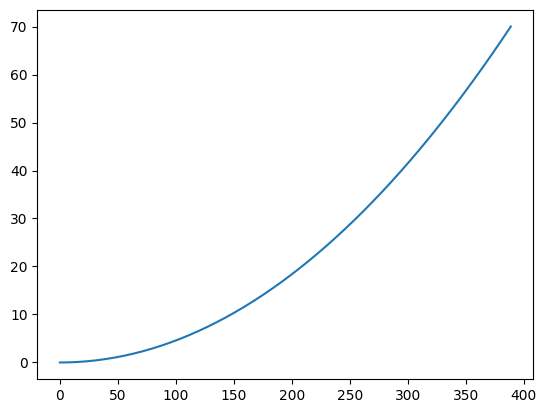

In [78]:
plt.plot(x0, z0)
plt.show()

In [79]:
q0=np.zeros(12*N)

In [80]:
for j in range(1,12):
    if j==1:
        q0[(j-1)*N:j*N]=x0
    elif j==5:
        q0[(j-1)*N:j*N]=z0

In [81]:
def static_func(Q): 
    t=0

    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2 )


############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ)
    C = (C1.T)
 
    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr',A0, Π(φ,θ,ψ))

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    # D[:, :] = 0                                                     ### !!! ### !!! ### !!! ###

    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 
    
    H = np.cross(D,np.einsum('ijk,ik->ij', A0, D))

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, C + G - L - H - np.einsum('ijk,ik->ij',A0, B)).T
#############################################
    
    ans=np.concatenate([dx, ddx, 
                        dy, ddy,  
                        dz, ddz, 
                        dφ, ddφ,  
                        dθ, ddθ, 
                        dψ, ddψ,  
                       ], axis=0)

    return ans

In [82]:
root_ = root(static_func, q0, method='lm')

In [83]:
root_

 message: The relative error between two consecutive iterates is at most 0.000000
 success: True
  status: 2
     fun: [ 0.000e+00  0.000e+00 ...  0.000e+00  0.000e+00]
       x: [ 0.000e+00  7.939e+00 ...  0.000e+00  0.000e+00]
   cov_x: None
  method: lm
    nfev: 608
    fjac: [[-1.100e+03  0.000e+00 ...  0.000e+00  0.000e+00]
           [ 0.000e+00 -1.406e+02 ...  0.000e+00  0.000e+00]
           ...
           [ 0.000e+00  0.000e+00 ... -0.000e+00  0.000e+00]
           [ 0.000e+00  0.000e+00 ...  0.000e+00 -0.000e+00]]
    ipvt: [201 450 ... 239 240]
     qtf: [-1.469e+02 -7.523e-01 ...  4.502e-17  3.079e-18]

In [84]:
x0_, z0_=root_.x[:N],root_.x[4*N:5*N]

In [85]:
q0 = root_.x                                            # start from static solution

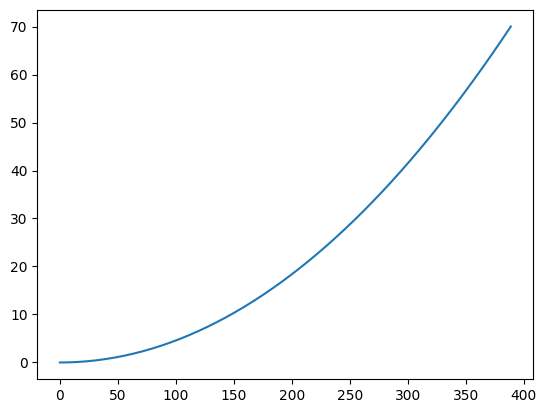

In [86]:
plt.plot(x0_, z0_)
plt.show()

### Vessle Simulation

In [87]:
sampleTime = 0.01              # sample time [seconds]
Number = 60000                      # number of samples

In [88]:
Number*sampleTime

600.0

In [89]:
vehicle=semisub('DPcontrol',1,-1,0.0,0,0)

In [90]:
[simTime, simData] = simulate(Number, sampleTime, vehicle)

In [91]:
simData.shape 

(60001, 24)

In [92]:
ans_t=[]
sum_=0
for i in range(simData.shape[0]):
    ans_t.append(sum_)
    sum_+=sampleTime

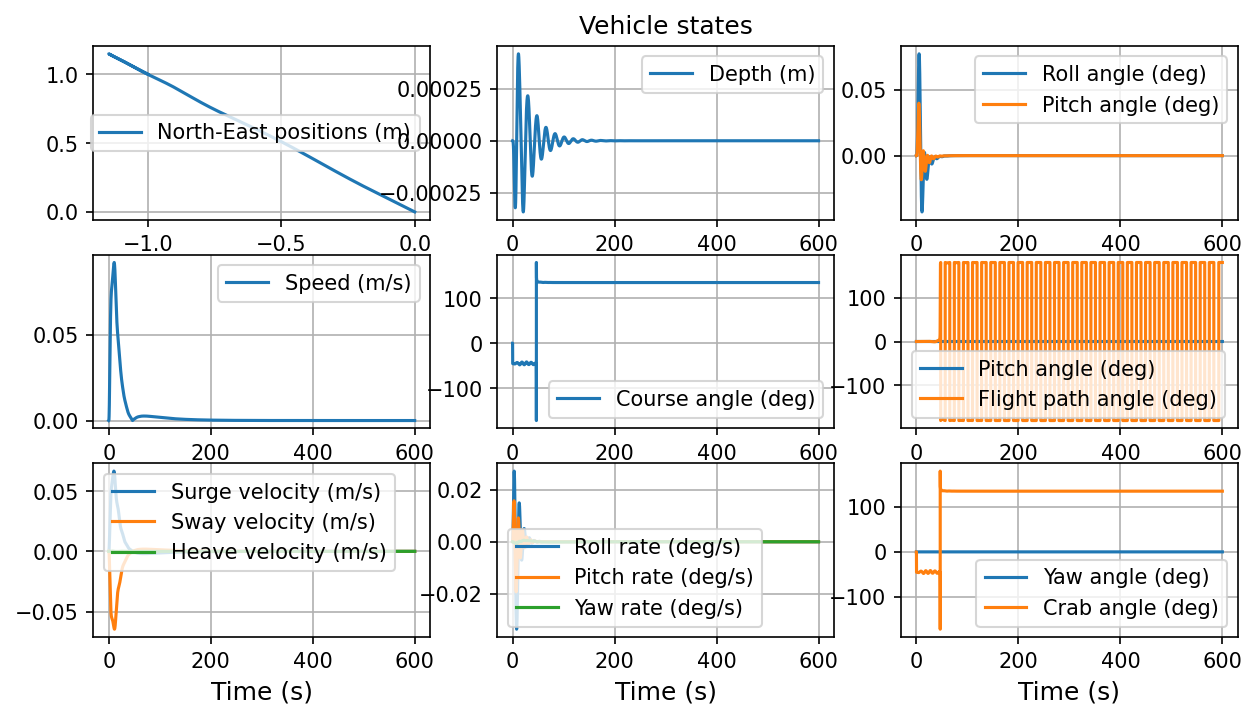

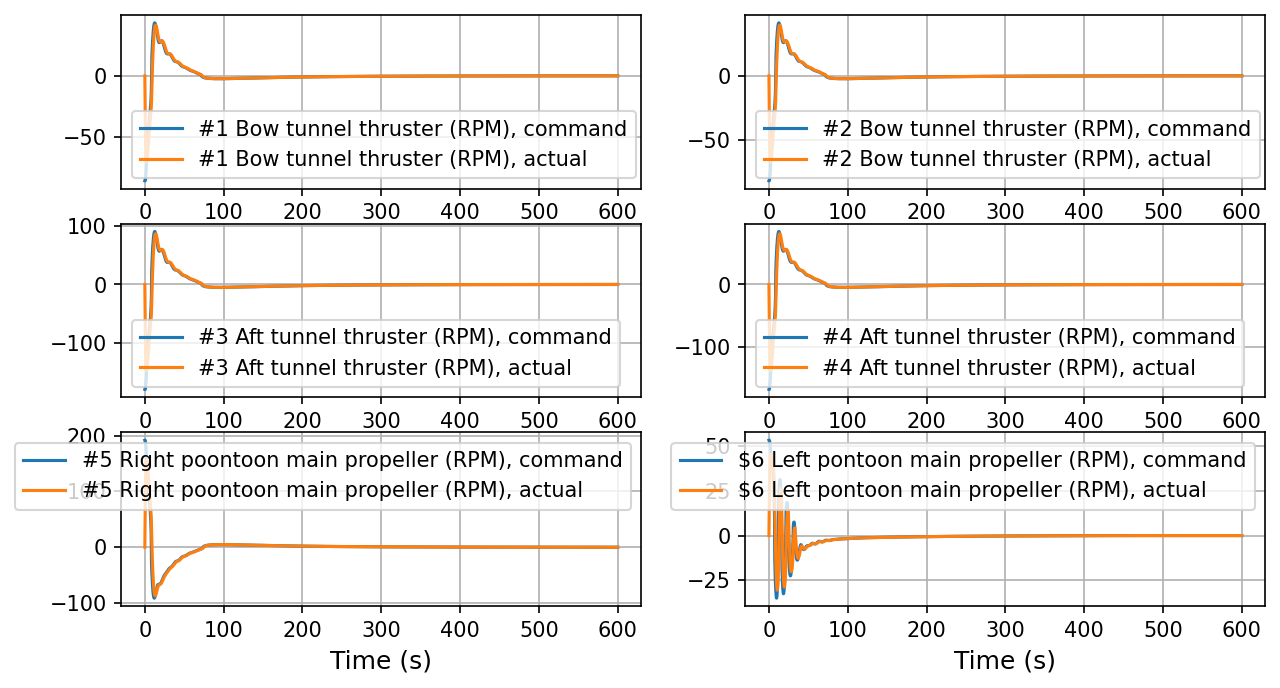

In [93]:
plotVehicleStates(simTime, simData, 1)
plotControls(simTime, simData, vehicle, 2)

In [94]:
numDataPoints = 5                 # number of 3D data points
FPS = 10                            # frames per second (animated GIF)
filename = '3D_animation.gif'       # data file for animated GIF
browser = 'safari'

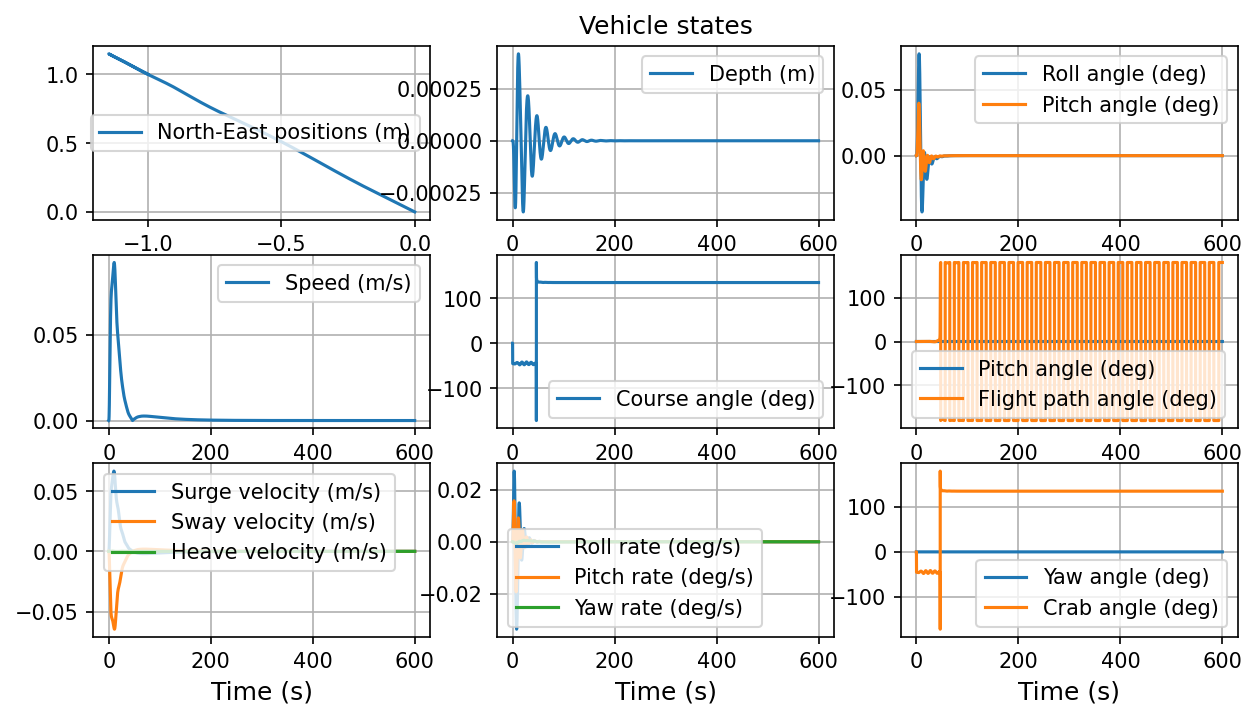

In [95]:
plotVehicleStates(simTime, simData, 3)

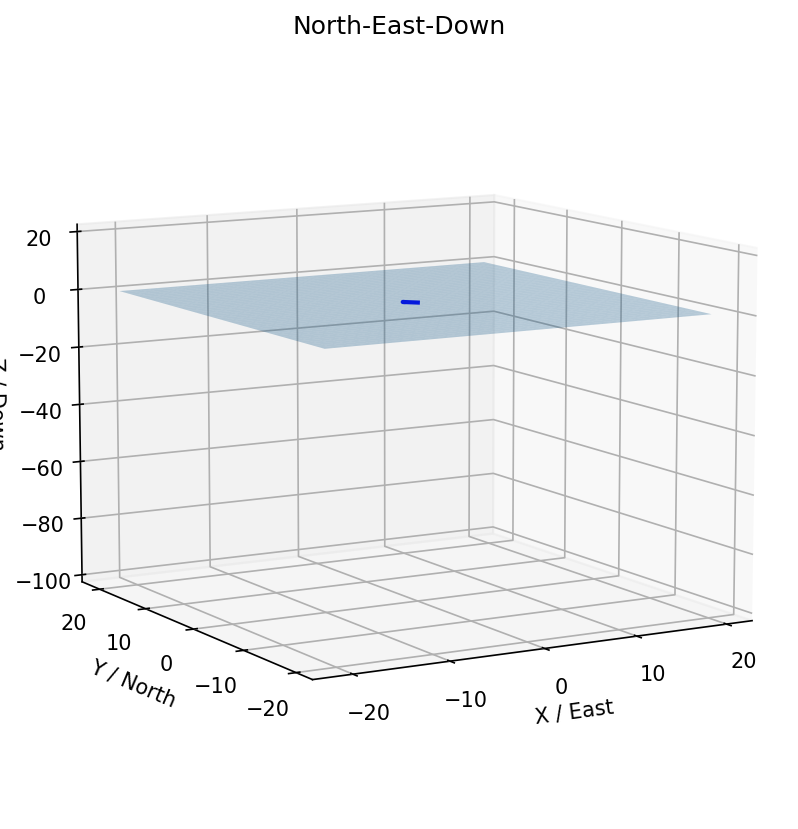

In [96]:
plot3D(simData, numDataPoints, FPS, filename, 3)

In [97]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

In [98]:
class MyTime:
    def __init__(self):
        self.my_t = 0
        self.v_m = np.array([0,0,0,0,0,0]).astype(np.float64)
        self.progression = [i for i in range(650)]
        self.wall_clock = datetime.now()
        self.x_ve = 0
        self.y_ve = 0
        self.z_ve = 0
        self.phi_ve = 0
        self.theta_ve = 0
        self.psi_ve = 0
        self.top_tension = 0
        self.sagbend_strain = 0
        self.my_iter = 0

In [99]:
vessel_motion_func = interp1d(
    ans_t, simData[:, 6:12], axis=0, kind="linear", fill_value="extrapolate"
)

### Dynamics

In [100]:
def dynamic_func(t, Q, T):
    
        
    x,y,z=Q[0:N],Q[2*N:3*N],Q[4*N:5*N]
    dx,dy,dz=Q[1*N:2*N],Q[3*N:4*N],Q[5*N:6*N]
    φ,θ,ψ=Q[6*N:7*N],Q[8*N:9*N],Q[10*N:11*N]
    dφ,dθ,dψ=Q[7*N:8*N],Q[9*N:10*N],Q[11*N:12*N]
    
    ve = vessel_motion_func(t)
    dx_ve = ve[0]
    dy_ve = ve[1]
    dz_ve = ve[2]
    dphi_ve = ve[3]
    dtheta_ve = ve[4]
    dpsi_ve = ve[5]
    
    s = np.linspace(0, 1, N)
    error_x=0.1*(s*dx_ve-dx)
    error_y=0.1*(s*dy_ve-dy)
    error_z=0.1*(s*dz_ve-dz)
    dx += error_x
    dy += error_y
    dz += error_z
    
    RET = Ret(φ,θ,ψ)
    
    Z1 = d_s(ne, x, y, z, φ, θ, ψ).T
    Z2 = ne_hat(x, y, z, dx, dy, dz, False).T
    Z = (Z1 + Z2)

############################################################
    ddx,ddy, ddz = (Z/mp).T
############################################################
    
    C1 = d_s(me, φ, θ, ψ, φ, θ, ψ).T
    C = C1

    A0 = Jrho(RET,Jrho0)
    A_fin = np.einsum('ijk,ikr->ijr', A0, Π(φ,θ,ψ))
    

    B = np.einsum('ijk,ik->ij', dΠ(φ, θ, ψ, dφ, dθ, dψ), np.stack((dφ,dθ,dψ), axis=1))

    error_φ=0.1*(s*dphi_ve-dφ)
    error_θ=0.1*(s*dtheta_ve-dθ)
    error_ψ=0.1*(s*dpsi_ve-dψ)
    dφ += error_φ
    dθ += error_θ
    dψ += error_ψ
    
    D = w_e(φ,θ,ψ,dφ,dθ,dψ)
    
    G = np.cross(d_s(phi,x,y,z,φ, θ, ψ).T, ne(x, y, z, φ, θ, ψ))
    
    L = np.einsum('ijk,ik->ij',RET, (DR@D.T).T) 

    H = np.cross(D, np.einsum('ijk,ik->ij', A0, D))
    

#############################################
    ddφ,ddθ,ddψ = np.linalg.solve(A_fin, (C + G - L - H - np.einsum('ijk,ik->ij', A0, B))).T
#############################################


    if t>T.progression[0]:
        T.progression.pop(0)
        print('Physical time: ', t, ' Iteration wall-clock time: ', datetime.now() - T.wall_clock )
        T.wall_clock = datetime.now()   
         

    ans=np.concatenate([dx, ddx, 
                            dy, ddy, 
                            dz, ddz, 
                            dφ, ddφ, 
                            dθ, ddθ,  
                            dψ, ddψ, 
                           ], axis=0)
   
   
    if t>1:
        ax=np.einsum('ijk,ik->ij',np.linalg.inv(RET),ne(x, y, z, φ, θ, ψ))
       
        T.top_tension=max(T.top_tension, np.max(ax[:,0]))            
        
        ben0=np.einsum('ijk,ik->ij',np.linalg.inv(RET), me(φ, θ, ψ, φ, θ, ψ))
        ben=np.max(ben0[:,1:])
        
        I=3.14*(d0**4-dI**4)/64
        strain=np.max(ben)*d0/(2*E*I)    
        
        T.sagbend_strain=max(T.sagbend_strain, strain)
    T.my_iter+=1
    
 
    return ans

In [101]:
T_ = MyTime()

# initial conditions - to control dynamics
q0[6*N:7*N], q0[8*N:9*N], q0[10*N:11*N] = (np.array([0.01 for i in range(N)]),
                                          np.array([0.00003 for i in range(N)]),
                                          np.array([0.001767*i/N for i in range(N)]))

In [102]:
startTime1 = datetime.now()
us_ = solve_ivp(dynamic_func,
             tspan,
             q0,
             args=(T_, ), 
               )
print(datetime.now() - startTime1)

Physical time:  6.0376224638449814e-09  Iteration wall-clock time:  0:00:00.018887
Physical time:  1.0004736581157867  Iteration wall-clock time:  0:00:02.878547
Physical time:  2.0045365099608228  Iteration wall-clock time:  0:00:02.657462
Physical time:  3.0006742036106373  Iteration wall-clock time:  0:00:02.796932
Physical time:  4.000930250363316  Iteration wall-clock time:  0:00:02.791108
Physical time:  5.0000691624970655  Iteration wall-clock time:  0:00:02.502120
Physical time:  6.004333295617546  Iteration wall-clock time:  0:00:02.646748
Physical time:  7.0072947566188715  Iteration wall-clock time:  0:00:03.188198
Physical time:  8.001506153238623  Iteration wall-clock time:  0:00:04.026668
Physical time:  9.009713354379395  Iteration wall-clock time:  0:00:02.939956
0:00:28.625334


### Results

In [103]:
# max axial tension
T_.top_tension

314696.1985113361

In [104]:
# max bending strain
T_.sagbend_strain

0.010713985183318434

In [105]:
fin=us_

In [106]:
fin

  message: The solver successfully reached the end of the integration interval.
  success: True
   status: 0
        t: [ 0.000e+00  6.038e-07 ...  9.993e+00  1.000e+01]
        y: [[ 0.000e+00  4.717e-26 ...  5.433e-03  5.438e-03]
            [ 7.939e+00  7.939e+00 ...  7.921e+00  7.921e+00]
            ...
            [ 0.000e+00 -5.450e-23 ... -7.211e-06 -7.243e-06]
            [ 0.000e+00 -1.253e-21 ... -7.361e-06 -7.394e-06]]
      sol: None
 t_events: None
 y_events: None
     nfev: 3074
     njev: 0
      nlu: 0

In [107]:
t=fin.t

In [108]:
fin=fin.y.T

In [109]:
t.shape, fin.shape

((500,), (500, 600))

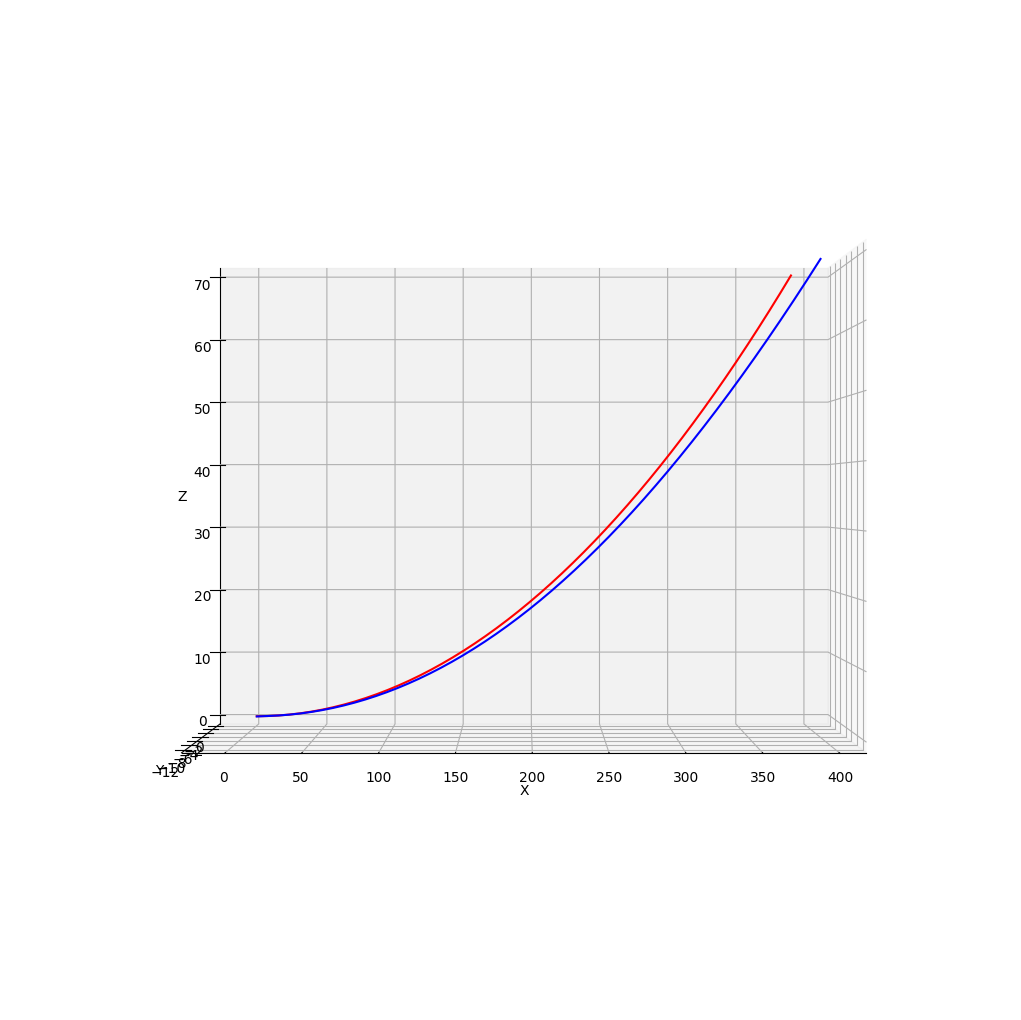

In [110]:
fig=plt.figure(figsize=(13,13))
ax = fig.add_subplot(projection = '3d')

X0=fin[0,[i for i in range(0,N)]]
Y0=fin[0,[i for i in range(2*N,3*N)]]
Z0=fin[0,[i for i in range(4*N,5*N)]]

j=-1
X=fin[j,[i for i in range(0,N)]]
Y=fin[j,[i for i in range(2*N,3*N)]]
Z=fin[j,[i for i in range(4*N,5*N)]]

num_true_pts = 200
tck, u = interpolate.splprep([X,Y,Z], s=2)
u_fine = np.linspace(0,1,num_true_pts)
x_fine, y_fine, z_fine = interpolate.splev(u_fine, tck)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.plot(X0,Y0,Z0, color='r')
ax.plot(X,Y,Z, color='b')
ax.view_init(0,-90)
plt.show()

In [111]:
X,Y,Z

(array([5.43771551e-03, 7.92145084e+00, 1.58428490e+01, 2.37644959e+01,
        3.16864759e+01, 3.96088842e+01, 4.75318241e+01, 5.54554046e+01,
        6.33797403e+01, 7.13049492e+01, 7.92311462e+01, 8.71584417e+01,
        9.50869423e+01, 1.03016747e+02, 1.10947934e+02, 1.18880556e+02,
        1.26814623e+02, 1.34750108e+02, 1.42686949e+02, 1.50625041e+02,
        1.58564232e+02, 1.66504349e+02, 1.74445210e+02, 1.82386625e+02,
        1.90328476e+02, 1.98270641e+02, 2.06212959e+02, 2.14155392e+02,
        2.22098027e+02, 2.30041150e+02, 2.37984999e+02, 2.45929607e+02,
        2.53875079e+02, 2.61821665e+02, 2.69769658e+02, 2.77719408e+02,
        2.85671545e+02, 2.93626392e+02, 3.01584045e+02, 3.09544783e+02,
        3.17509035e+02, 3.25476802e+02, 3.33446754e+02, 3.41417834e+02,
        3.49389984e+02, 3.57363137e+02, 3.65337373e+02, 3.73313043e+02,
        3.81291383e+02, 3.89274495e+02]),
 array([ 1.63131495e-05,  1.84375342e-02,  2.62032174e-02,  2.32608508e-02,
         9.5731645

In [112]:
X0,Y0,Z0

(array([  0.        ,   7.93932869,  15.87865737,  23.81798606,
         31.75731475,  39.69664344,  47.63597212,  55.57530081,
         63.5146295 ,  71.45395818,  79.39328687,  87.33261556,
         95.27194424, 103.21127293, 111.15060162, 119.08993031,
        127.02925899, 134.96858768, 142.90791637, 150.84724505,
        158.78657374, 166.72590243, 174.66523111, 182.6045598 ,
        190.54388849, 198.48321718, 206.42254586, 214.36187455,
        222.30120324, 230.24053192, 238.17986061, 246.1191893 ,
        254.05851798, 261.99784667, 269.93717536, 277.87650405,
        285.81583273, 293.75516142, 301.69449011, 309.63381879,
        317.57314748, 325.51247617, 333.45180485, 341.39113354,
        349.33046223, 357.26979092, 365.2091196 , 373.14844829,
        381.08777698, 389.02710566]),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.

In [113]:
us=fin.T

In [114]:
us.shape

(600, 500)

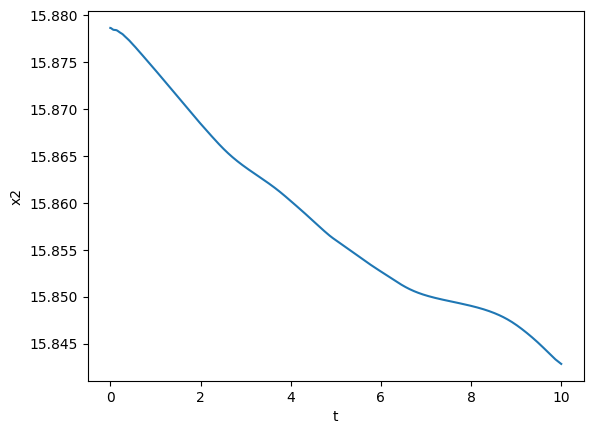

In [115]:
plt.plot(t,us.T[:,2],'-')
plt.xlabel('t')
plt.ylabel('x2')
plt.show()

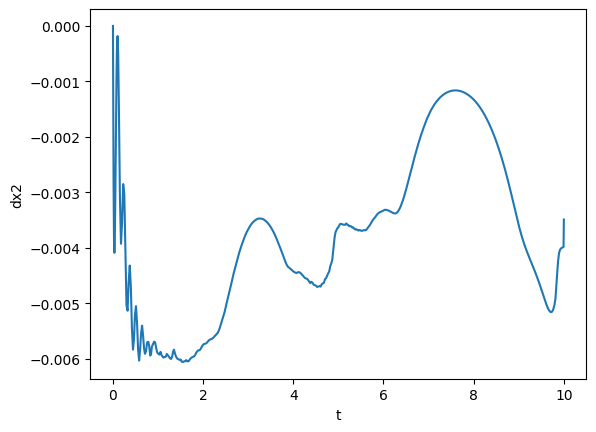

In [116]:
plt.plot(t,us.T[:,N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dx2')
plt.show()

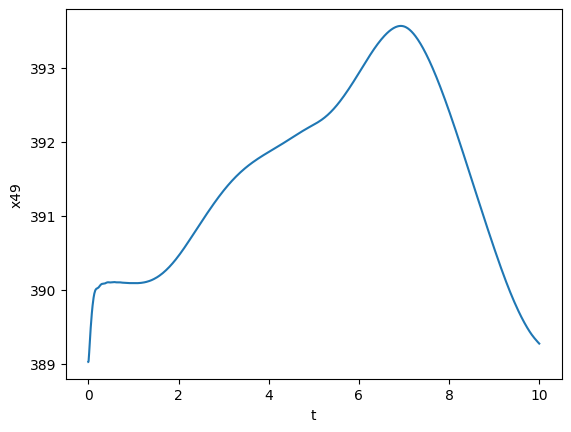

In [117]:
plt.plot(t,us.T[:,N-1] ,'-')
plt.xlabel('t')
plt.ylabel('x{}'.format(N-1))
plt.show()

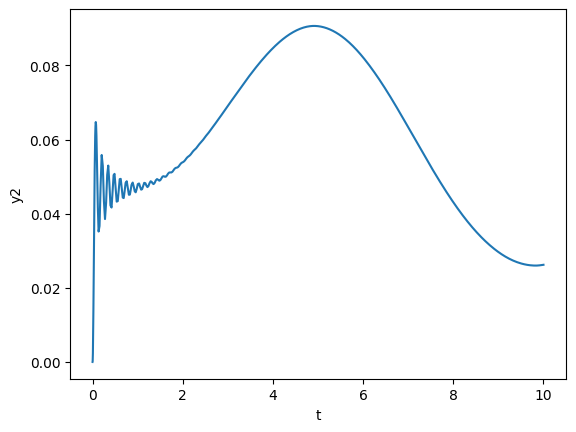

In [118]:
plt.plot(t,us.T[:,2*N +2] ,'-')
plt.xlabel('t')
plt.ylabel('y2')
plt.show()

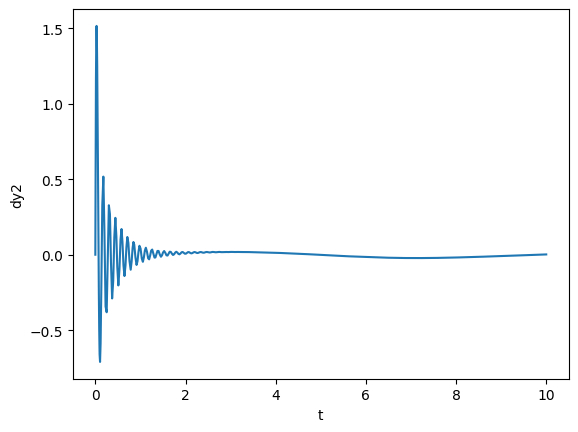

In [119]:
plt.plot(t,us.T[:,3*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dy2')
plt.show()

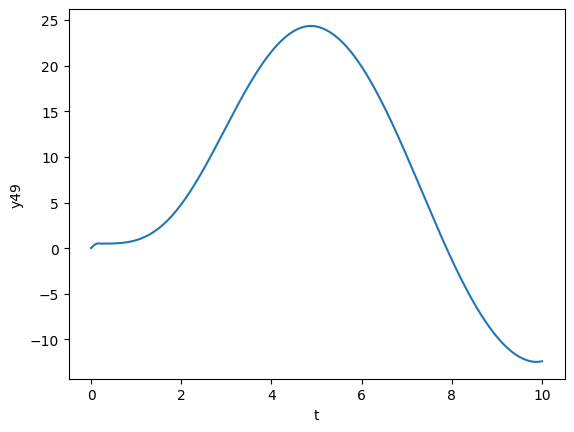

In [120]:
plt.plot(t,us.T[:,2*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('y{}'.format(N-1))
plt.show()

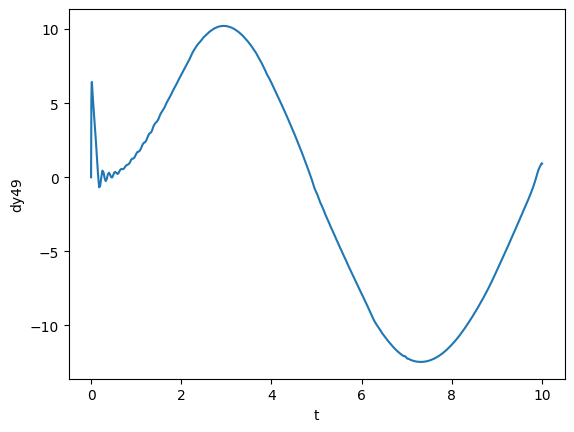

In [121]:
plt.plot(t,us.T[:,3*N+(N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('dy{}'.format(N-1))
plt.show()

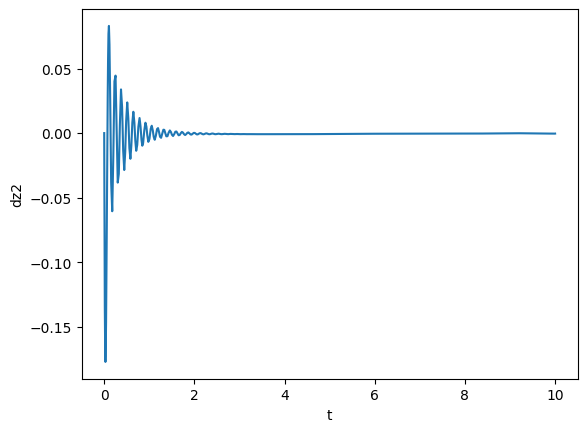

In [122]:
plt.plot(t,us.T[:,5*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dz2')
plt.show()

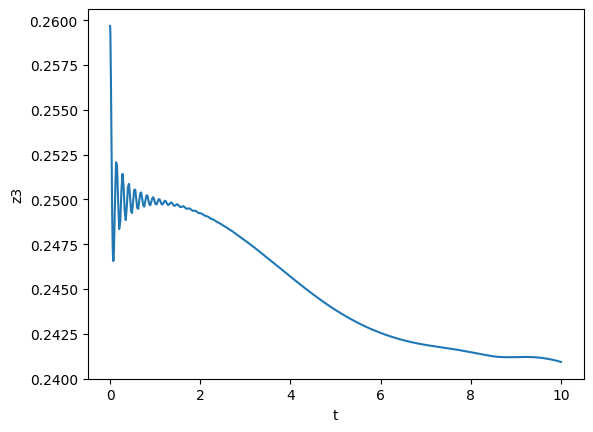

In [123]:
plt.plot(t,us.T[:,4*N+3] ,'-')
plt.xlabel('t')
plt.ylabel('z3')
plt.show()

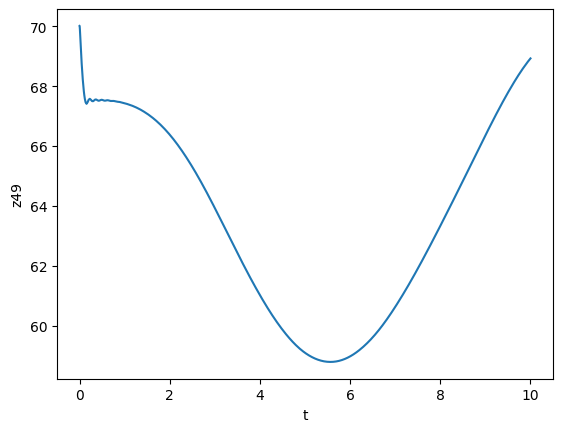

In [124]:
plt.plot(t,us.T[:,4*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('z{}'.format(N-1))
plt.show()

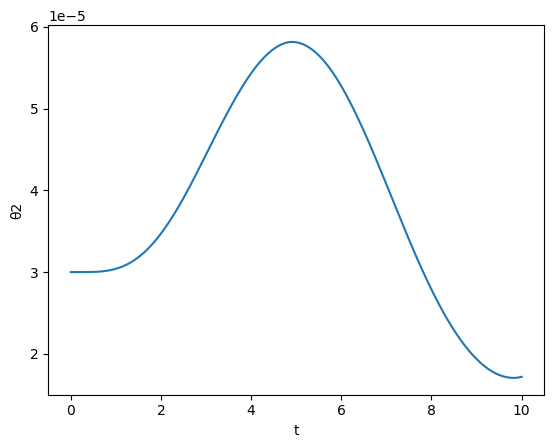

In [125]:
plt.plot(t,us.T[:,8*N+2],'-')
plt.xlabel('t')
plt.ylabel('θ2')
plt.show()

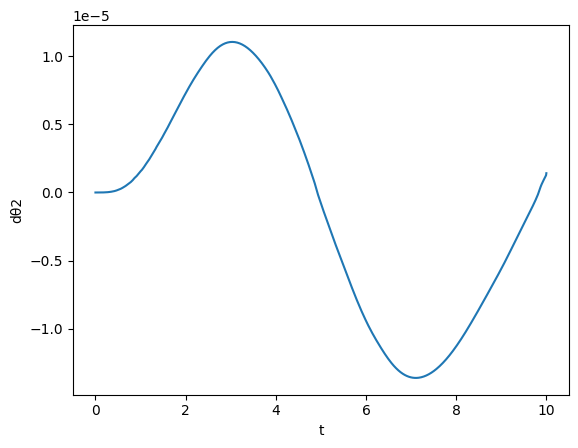

In [126]:
plt.plot(t,us.T[:,9*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dθ2')
plt.show()

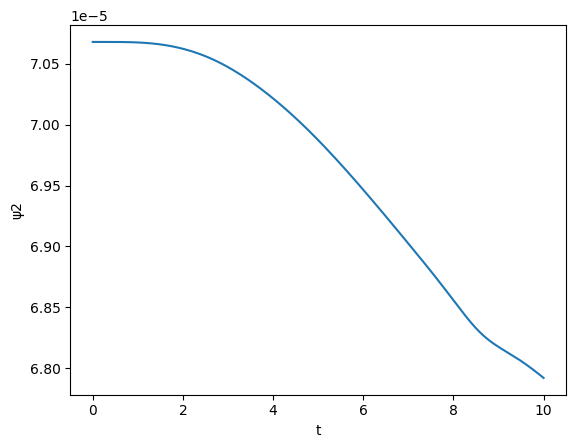

In [127]:
plt.plot(t,us.T[:,10*N+2],'-')
plt.xlabel('t')
plt.ylabel('ψ2')
plt.show()

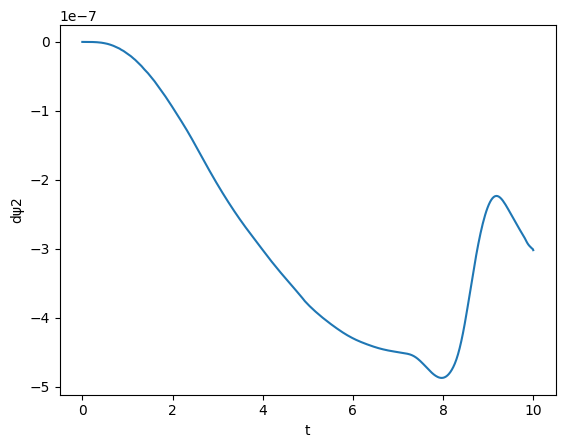

In [128]:
plt.plot(t,us.T[:,11*N+2] ,'-')
plt.xlabel('t')
plt.ylabel('dψ2')
plt.show()

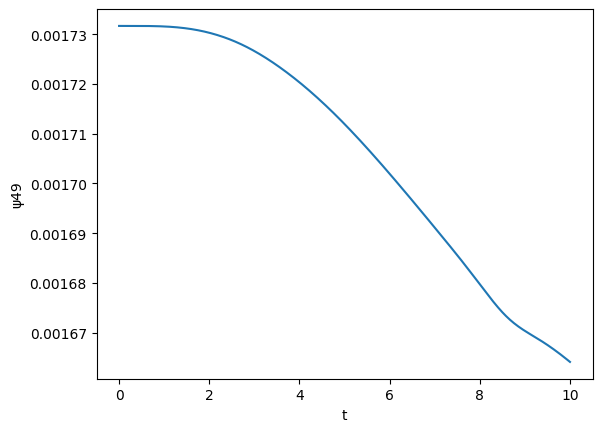

In [129]:
plt.plot(t,us.T[:,10*N + (N-1)] ,'-')
plt.xlabel('t')
plt.ylabel('ψ{}'.format(N-1))
plt.show()

In [130]:
X010=us.T[:,0*N:1*N]

In [131]:
Y010=us.T[:,2*N:3*N]

In [132]:
Z010=us.T[:,4*N:5*N]

In [133]:
# simulation = np.stack([X010,Y010,Z010],axis=2) 

# FPS = 5                      
# frame_duration = 1000 / FPS

# frames = []
# for t in range(simulation.shape[0]):
#     x = simulation[t,:,0]
#     y = simulation[t,:,1]
#     z = simulation[t,:,2]

#     frames.append(go.Frame(
#         data=[
#             go.Scatter3d(
#                 x=x, y=y, z=z,
#                 mode="lines+markers",
#                 marker=dict(size=5, color=list(range(12)), colorscale="Viridis"),
#                 line=dict(width=4)
#             )
#         ],
#         name=f"t={t}"
#     ))

# # First frame
# x0, y0, z0 = simulation[0,:,0], simulation[0,:,1], simulation[0,:,2]

# fig = go.Figure(
#     data=[go.Scatter3d(x=x0, y=y0, z=z0, mode="lines+markers")],
#     frames=frames
# )

# # Animation controls
# fig.update_layout(
#     title="Pipeline Simulation ",
#     scene=dict(
#         xaxis_title="X",
#         yaxis_title="Y",
#         zaxis_title="Z",
#         xaxis=dict(range=[0, 400]),
#         yaxis=dict(range=[-50, 50]),
#         zaxis=dict(range=[0, 100]),
#         aspectmode="data",
       
#     ),
#     updatemenus=[{
#         "type": "buttons",
#         "buttons": [
#             {
#                 "label": "Play",
#                 "method": "animate",
#                 "args": [None, {"frame": {"duration": frame_duration, "redraw": True}}]
#             },
#             {
#                 "label": "Pause",
#                 "method": "animate",
#                 "args": [[None], {"frame": {"duration": 0}}]
#             }
#         ]
#     }]
# )

# fig.show()